# US Customer Insights — Exploratory Data Analysis
> **Dataset:** US_Customer_Insights_Dataset.csv  
> **Objective:** End-to-end EDA covering data understanding, descriptive statistics, visualization, bivariate analysis, hypothesis testing, and business insights.

In [1]:
# Core imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'axes.labelsize': 10,
})
PALETTE = ['#2E4057', '#F76F53', '#48CAE4', '#06D6A0', '#FFD166']
PRIMARY, ACCENT = '#2E4057', '#F76F53'

---
## Step 1 — Understand Your Data
Load the dataset, inspect its structure, and check data quality.

In [2]:
df = pd.read_csv('US_Customer_Insights_Dataset.csv')
print(f'Shape: {df.shape[0]:,} rows * {df.shape[1]} columns')
df.head()

Shape: 10,675 rows * 12 columns


,CustomerID,Name,State,Education,Gender,Age,Married,NumPets,JoinDate,TransactionDate,MonthlySpend,DaysSinceLastInteraction
0,CUST10319,Scott Perez,Florida,High School,Non-Binary,47,Yes,1,9/19/21,09-02-2024,1281.74,332
1,CUST10695,Jennifer Burton,Washington,Master,Male,72,Yes,0,04-05-2024,06-02-2024,429.46,424
2,CUST10297,Michelle Rogers,Arizona,Master,Female,40,Yes,2,7/24/24,2/28/25,510.34,153
3,CUST10103,Brooke Hendricks,Texas,Master,Male,27,Yes,0,08-12-2023,3/29/25,396.47,124
4,CUST10219,Karen Johns,Texas,High School,Female,28,Yes,1,12-06-2021,7/24/22,139.68,1103


In [3]:
# Data types and field classification
type_info = pd.DataFrame({
    'Dtype': df.dtypes,
    'Non-Null': df.notnull().sum(),
    'Null': df.isnull().sum(),
    'Unique Values': df.nunique(),
    'Field Type': [
        'Identifier', 'Attribute', 'Categorical', 'Categorical', 'Categorical',
        'Numerical', 'Categorical', 'Numerical', 'Temporal', 'Temporal',
        'Numerical', 'Numerical'
    ]
})
type_info

,Dtype,Non-Null,Null,Unique Values,Field Type
CustomerID,object,10675,0,1000,Identifier
Name,object,10675,0,990,Attribute
State,object,10675,0,10,Categorical
Education,object,10675,0,5,Categorical
Gender,object,10675,0,3,Categorical
Age,int64,10675,0,63,Numerical
Married,object,10675,0,2,Categorical
NumPets,int64,10675,0,5,Numerical
JoinDate,object,10675,0,731,Temporal
TransactionDate,object,10675,0,1605,Temporal


In [4]:
# Check for missing values and duplicates
print('=== Missing Values ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else 'No missing values ✓')

print('=== Duplicate Rows ===')
dups = df.duplicated().sum()
print(f'{dups} duplicate rows found' if dups else 'No duplicates ✓')

=== Missing Values ===
No missing values ✓
=== Duplicate Rows ===
No duplicates ✓


In [5]:
# Parse date columns for potential temporal analysis
df['JoinDate'] = pd.to_datetime(df['JoinDate'], errors='coerce')
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'], errors='coerce')

# Confirm numerical vs categorical columns
num_cols = ['Age', 'NumPets', 'MonthlySpend', 'DaysSinceLastInteraction']
cat_cols = ['State', 'Education', 'Gender', 'Married']
temporal_cols = ['JoinDate', 'TransactionDate']
print('Numerical columns:', num_cols)
print('Categorical columns:', cat_cols)
print('Temporal columns:', temporal_cols)

Numerical columns: ['Age', 'NumPets', 'MonthlySpend', 'DaysSinceLastInteraction']
Categorical columns: ['State', 'Education', 'Gender', 'Married']
Temporal columns: ['JoinDate', 'TransactionDate']


**Summary — Step 1:**  
- Dataset has **10,675 rows** and **12 columns** — no missing values or duplicates.
- **4 numerical fields** (Age, NumPets, MonthlySpend, DaysSinceLastInteraction), **4 categorical** (State, Education, Gender, Married), **2 temporal** (JoinDate, TransactionDate), **1 identifiers** (CustomerID) and **1 Attribute** (Name).
- `MonthlySpend` is the primary variable of business interest.

---
## Step 2 — Descriptive Statistics
Compute summary metrics for numerical and categorical fields.

In [6]:
# Numerical summary (mean, median, std, min, max)
num_summary = df[num_cols].agg(['mean', 'median', 'std', 'min', 'max']).T
num_summary.columns = ['Mean', 'Median', 'Std Dev', 'Min', 'Max']
num_summary.round(2)

,Mean,Median,Std Dev,Min,Max
Age,49.47,49.00,18.22,18.00,80.00
NumPets,1.34,1.00,1.15,0.00,4.00
MonthlySpend,331.61,282.11,225.80,3.89,1740.42
DaysSinceLastInteraction,538.47,445.00,398.77,1.00,1791.00


In [7]:
# Skewness and kurtosis for numerical fields
skew_kurt = pd.DataFrame({
    'Skewness': df[num_cols].skew().round(3),
    'Kurtosis': df[num_cols].kurt().round(3)
})
print('--- Skewness & Kurtosis ---')
print(skew_kurt)
print('\nNote: MonthlySpend skewness > 0 confirms right-skewed distribution.')

--- Skewness & Kurtosis ---
                          Skewness  Kurtosis
Age                         -0.016    -1.205
NumPets                      0.563    -0.465
MonthlySpend                 1.422     3.042
DaysSinceLastInteraction     0.801    -0.113

Note: MonthlySpend skewness > 0 confirms right-skewed distribution.


In [8]:
# Categorical: mode and frequency tables
for col in cat_cols:
    freq = df[col].value_counts()
    print(f'\n--- {col} (Mode: "{freq.index[0]}") ---')
    print(freq.to_frame('Count').assign(Pct=lambda x: (x['Count'] / len(df) * 100).round(1)))


--- State (Mode: "California") ---
            Count   Pct
State                  
California   1180  11.1
Florida      1152  10.8
Ohio         1145  10.7
Arizona      1087  10.2
New York     1085  10.2
Georgia      1080  10.1
Washington   1030   9.6
Colorado     1014   9.5
Texas         997   9.3
Illinois      905   8.5

--- Education (Mode: "Master") ---
             Count   Pct
Education               
Master        2269  21.3
Associate     2153  20.2
Bachelor      2127  19.9
High School   2120  19.9
PhD           2006  18.8

--- Gender (Mode: "Male") ---
            Count   Pct
Gender                 
Male         3791  35.5
Non-Binary   3471  32.5
Female       3413  32.0

--- Married (Mode: "No") ---
         Count   Pct
Married             
No        5583  52.3
Yes       5092  47.7


**Summary — Step 2:**
- **MonthlySpend:** Mean \$331.61 vs median \$282.11 — right-skewed; a small cohort of high spenders inflates the mean.
- **DaysSinceLastInteraction:** Median 445 days (>1 year!) — the typical customer is very inactive.
- **Age** is approximately uniformly distributed (mean ≈ median ≈ 49).
- **Gender** is nearly balanced across Male/Female/Non-Binary. **Education** is evenly spread across all 5 levels.

---
## Step 3 — Data Visualization
Well-labeled charts revealing patterns across all key variables.

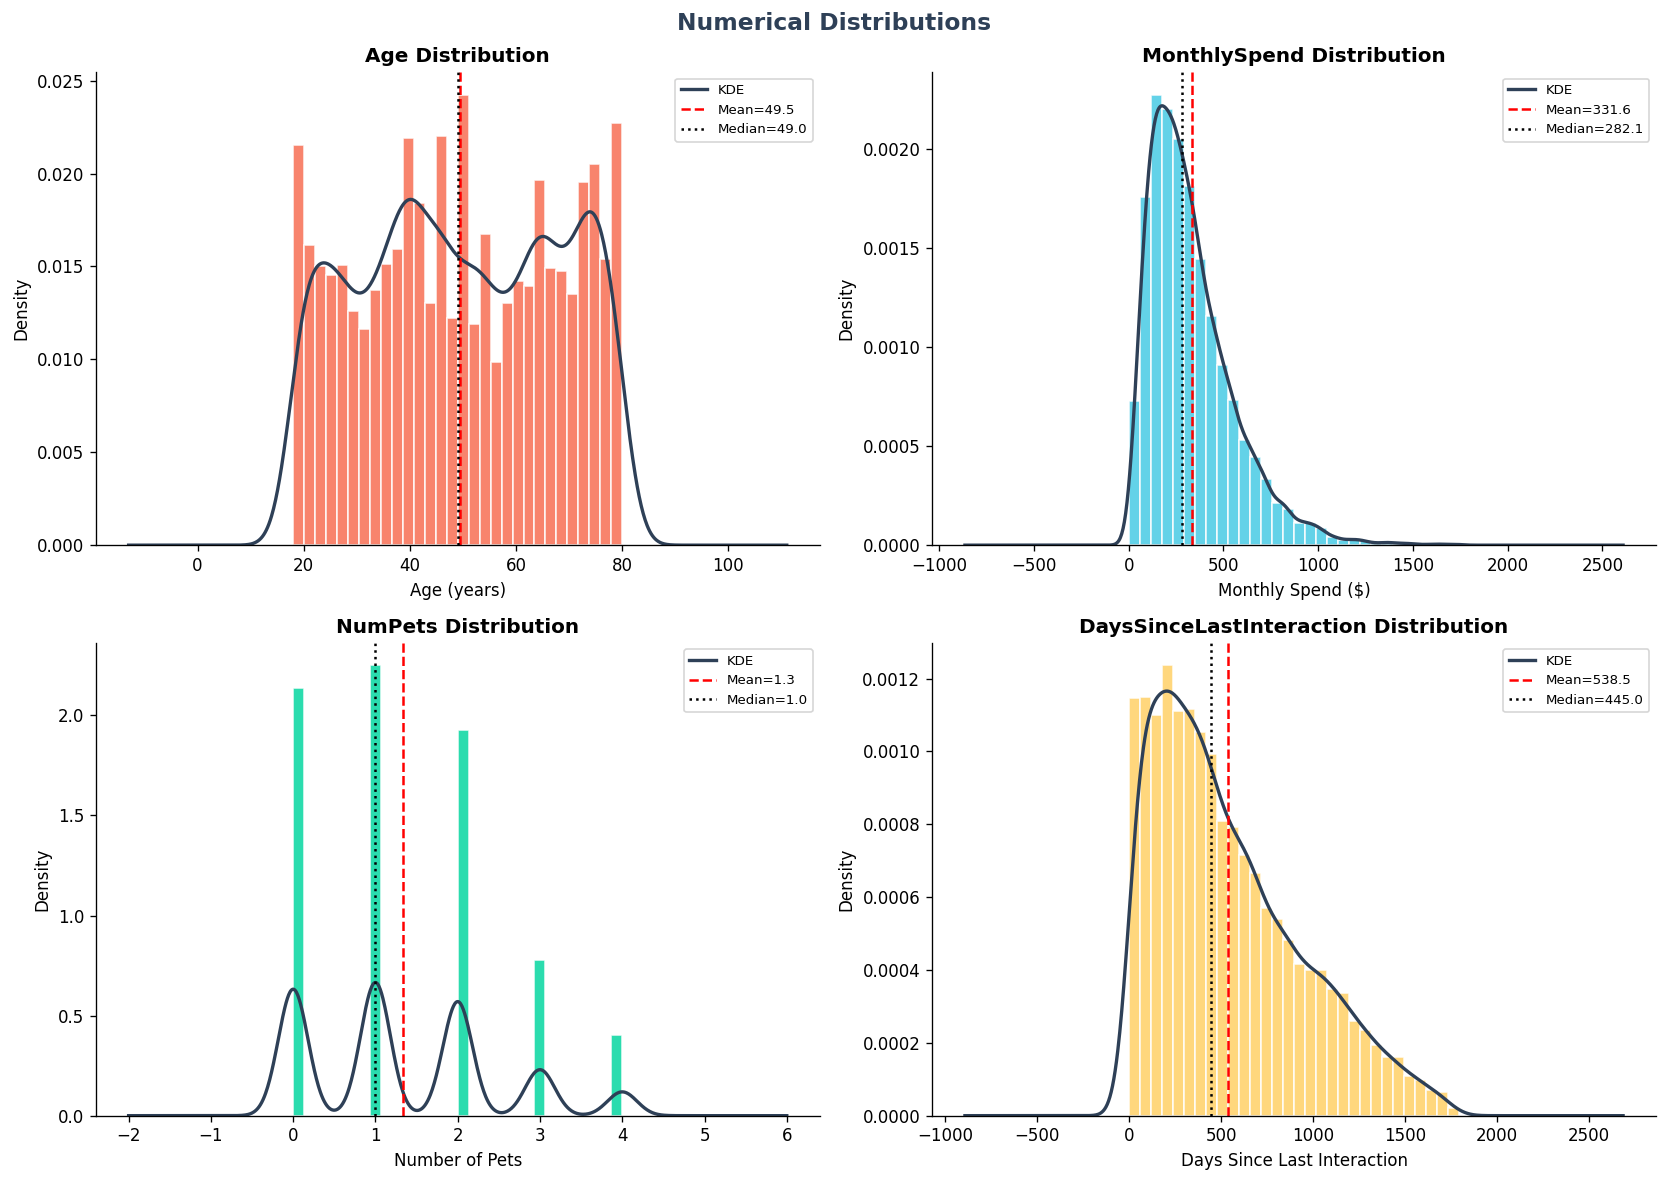

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Numerical Distributions', fontsize=14, fontweight='bold', color=PRIMARY)

chart_cfg = [
    ('Age', ACCENT, 'Age (years)'),
    ('MonthlySpend', '#48CAE4', 'Monthly Spend ($)'),
    ('NumPets', '#06D6A0', 'Number of Pets'),
    ('DaysSinceLastInteraction', '#FFD166', 'Days Since Last Interaction'),
]

for ax, (col, color, xlabel) in zip(axes.flat, chart_cfg):
    ax.hist(df[col], bins=30, color=color, edgecolor='white', alpha=0.85, density=True)
    df[col].plot.kde(ax=ax, color=PRIMARY, lw=2, label='KDE')
    ax.axvline(df[col].mean(), color='red', linestyle='--', lw=1.5, label=f'Mean={df[col].mean():.1f}')
    ax.axvline(df[col].median(), color='black', linestyle=':', lw=1.5, label=f'Median={df[col].median():.1f}')
    ax.set_title(f'{col} Distribution')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig1_distributions.png', bbox_inches='tight')
plt.show()

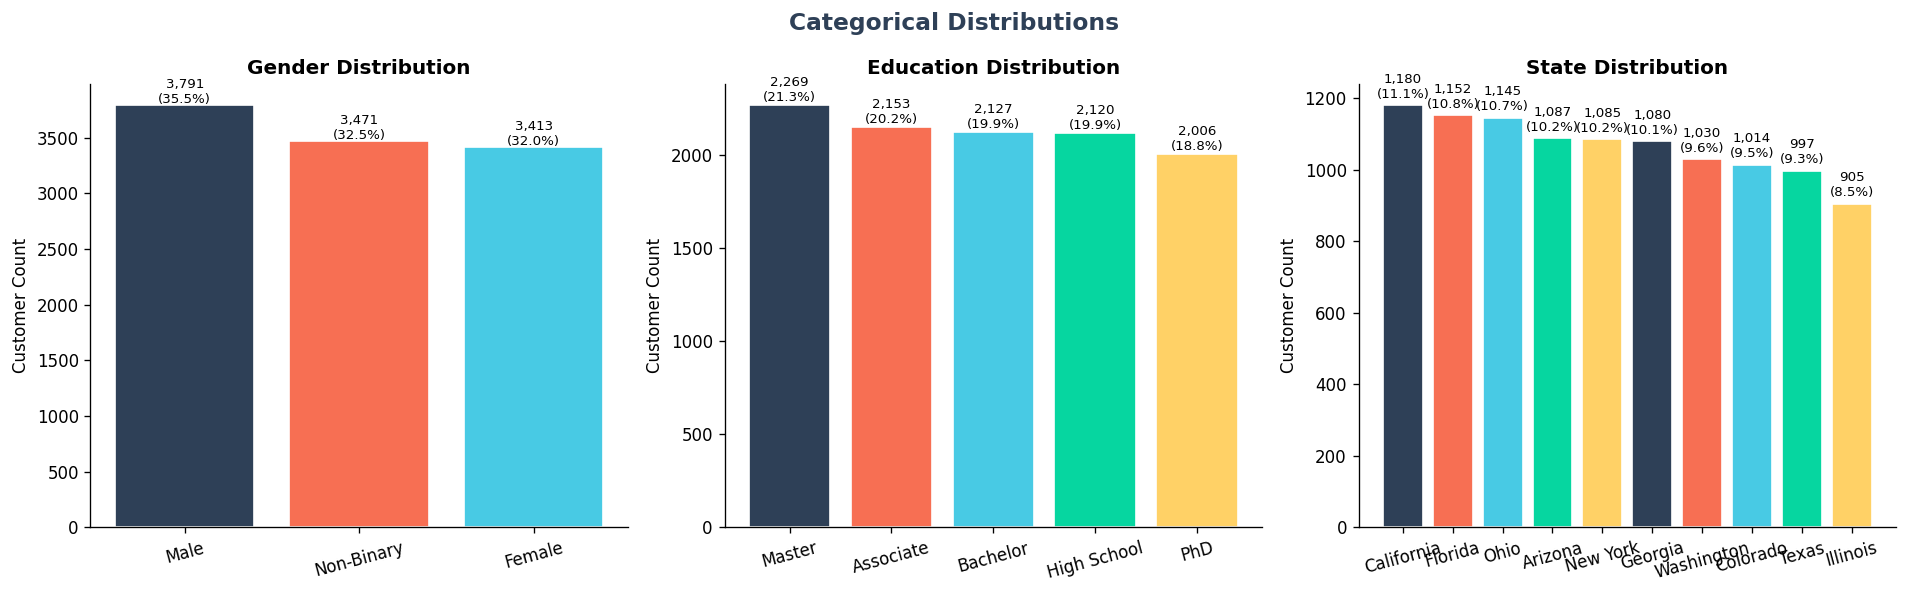

In [10]:
# Bar charts for categorical fields
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Categorical Distributions', fontsize=14, fontweight='bold', color=PRIMARY)

for ax, col in zip(axes, ['Gender', 'Education', 'State']):
    counts = df[col].value_counts()
    bars = ax.bar(counts.index, counts.values, color=PALETTE[:len(counts)], edgecolor='white')
    ax.set_title(f'{col} Distribution')
    ax.set_ylabel('Customer Count')
    ax.tick_params(axis='x', rotation=15)
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('fig2_categorical.png', bbox_inches='tight')
plt.show()

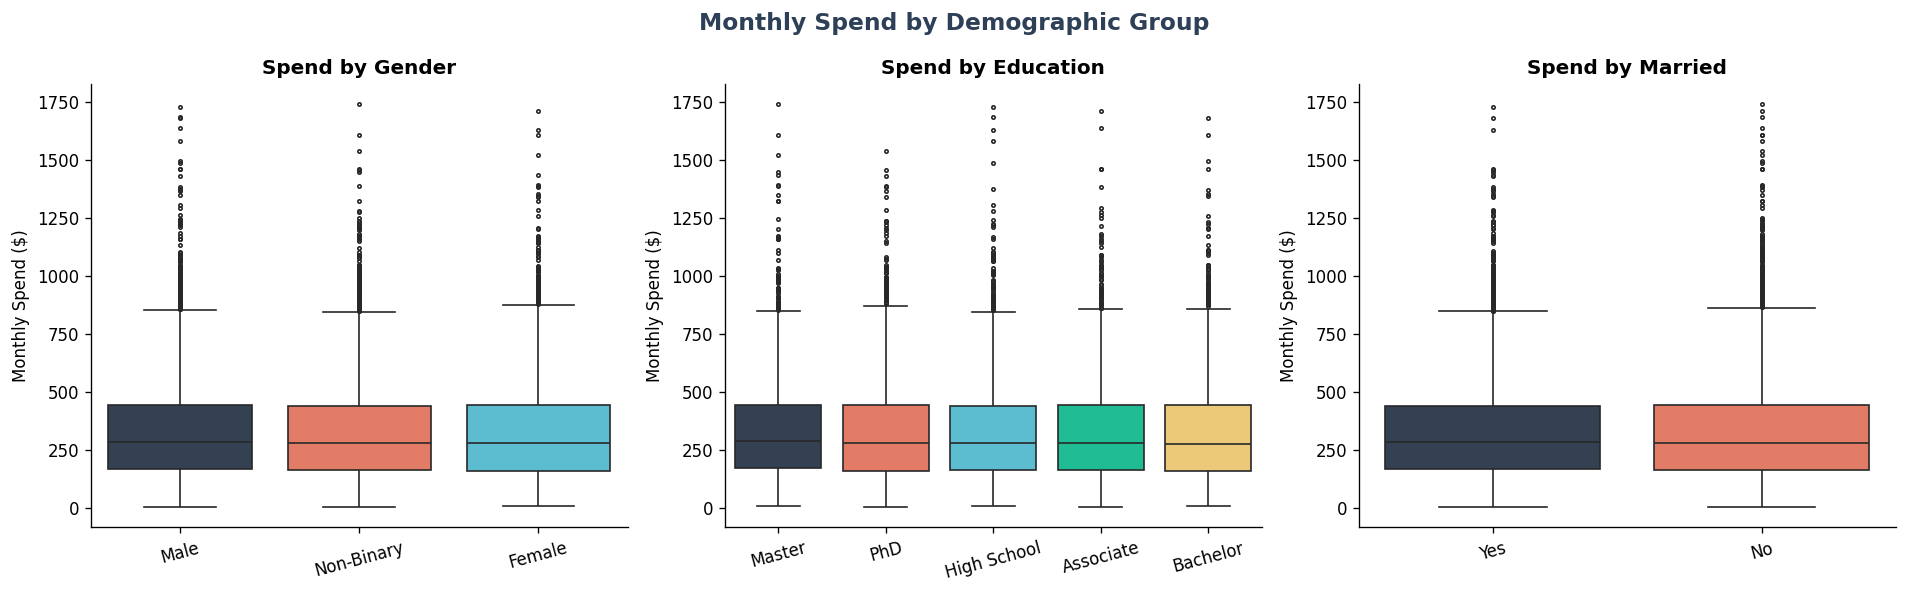

In [11]:
# Boxplots: MonthlySpend across categorical groups
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Monthly Spend by Demographic Group', fontsize=14, fontweight='bold', color=PRIMARY)

for ax, col in zip(axes, ['Gender', 'Education', 'Married']):
    order = df.groupby(col)['MonthlySpend'].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x=col, y='MonthlySpend', order=order,
                palette=PALETTE[:df[col].nunique()], ax=ax, fliersize=2, linewidth=1)
    ax.set_title(f'Spend by {col}')
    ax.set_xlabel('')
    ax.set_ylabel('Monthly Spend ($)')
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('fig3_boxplots.png', bbox_inches='tight')
plt.show()

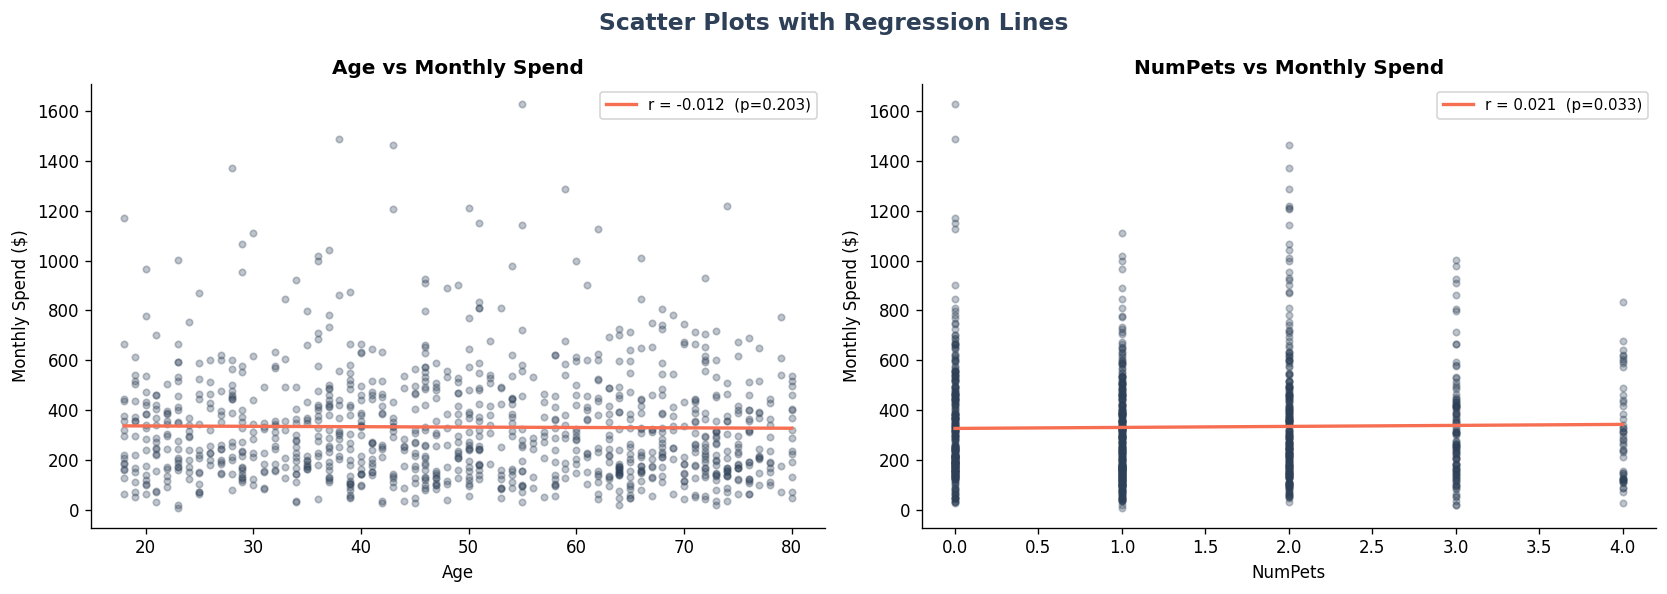

In [12]:
# Scatter plots: Age and NumPets vs MonthlySpend
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Scatter Plots with Regression Lines', fontsize=14, fontweight='bold', color=PRIMARY)

sample = df.sample(1000, random_state=42)  # sample for readability

for ax, xcol in zip(axes, ['Age', 'NumPets']):
    ax.scatter(sample[xcol], sample['MonthlySpend'], alpha=0.3, color=PRIMARY, s=15)
    m, b, r, p, _ = stats.linregress(df[xcol], df['MonthlySpend'])
    x_rng = np.array([df[xcol].min(), df[xcol].max()])
    ax.plot(x_rng, m * x_rng + b, color=ACCENT, lw=2, label=f'r = {r:.3f}  (p={p:.3f})')
    ax.set_title(f'{xcol} vs Monthly Spend')
    ax.set_xlabel(xcol)
    ax.set_ylabel('Monthly Spend ($)')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig4_scatter.png', bbox_inches='tight')
plt.show()

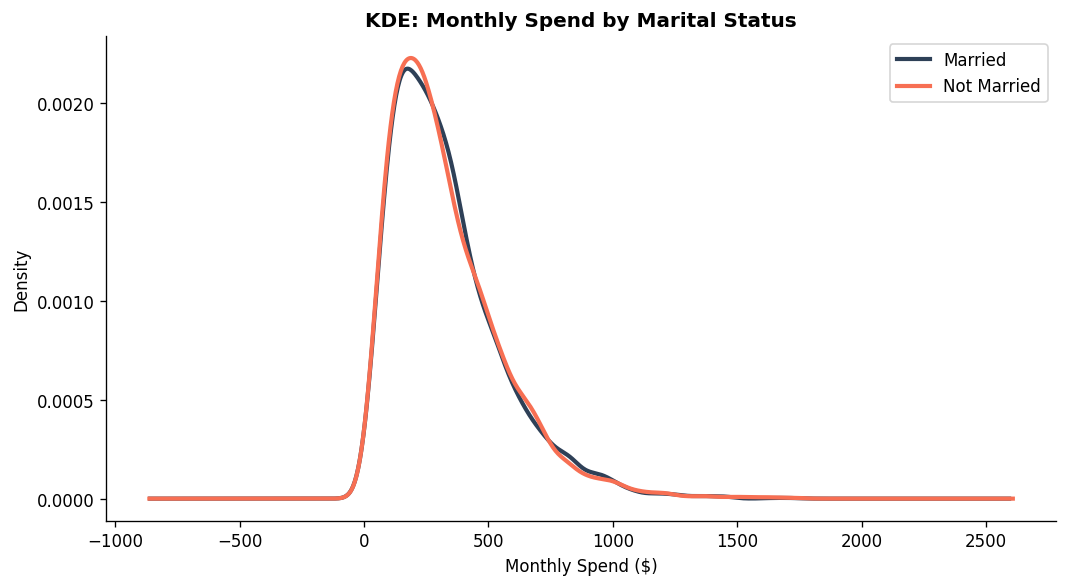

In [13]:
# KDE plot: MonthlySpend by Married status
fig, ax = plt.subplots(figsize=(9, 5))
for label, grp, color in zip(['Married', 'Not Married'],
                               [df[df['Married']=='Yes'], df[df['Married']=='No']],
                               [PRIMARY, ACCENT]):
    grp['MonthlySpend'].plot.kde(ax=ax, color=color, lw=2.5, label=label)

ax.set_title('KDE: Monthly Spend by Marital Status', fontweight='bold')
ax.set_xlabel('Monthly Spend ($)')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.savefig('fig5_kde_married.png', bbox_inches='tight')
plt.show()

**Visual Insights:**
- MonthlySpend is **right-skewed** — a long tail of high spenders above ~\$800.
- DaysSinceLastInteraction is roughly **right-skewed** — most customers haven't interacted in 200–600 days.
- Boxplots reveal **minimal spread difference** across gender, education, and marital status — groups look nearly identical.
- Regression lines on scatter plots are almost **flat**, hinting at very weak linear relationships.

---
## Step 4 — Bivariate Analysis
Correlations, crosstabs, and grouped summaries to uncover relationships.

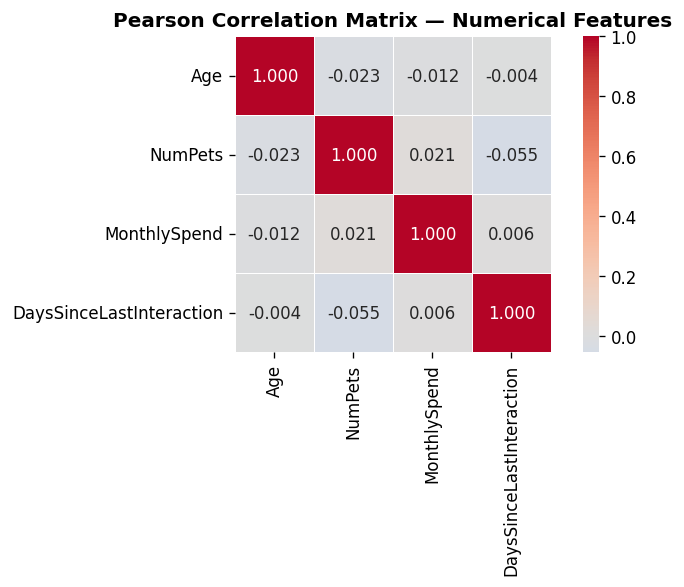

                             Age  NumPets  MonthlySpend  \
Age                       1.0000  -0.0230       -0.0123   
NumPets                  -0.0230   1.0000        0.0206   
MonthlySpend             -0.0123   0.0206        1.0000   
DaysSinceLastInteraction -0.0040  -0.0552        0.0061   

                          DaysSinceLastInteraction  
Age                                        -0.0040  
NumPets                                    -0.0552  
MonthlySpend                                0.0061  
DaysSinceLastInteraction                    1.0000  


In [14]:
# Pearson correlation matrix for numerical columns
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            ax=ax, linewidths=0.5, square=True)
ax.set_title('Pearson Correlation Matrix — Numerical Features', fontweight='bold')
plt.tight_layout()
plt.savefig('fig6_heatmap.png', bbox_inches='tight')
plt.show()
print(corr.round(4))

In [15]:
# Grouped summary: MonthlySpend by each categorical variable
print('=== Monthly Spend by Gender ===')
print(df.groupby('Gender')['MonthlySpend'].agg(['mean','median','std','count']).round(2))

print('\n=== Monthly Spend by Education ===')
print(df.groupby('Education')['MonthlySpend'].agg(['mean','median','std','count']).round(2))

print('\n=== Monthly Spend by Married ===')
print(df.groupby('Married')['MonthlySpend'].agg(['mean','median','std','count']).round(2))

=== Monthly Spend by Gender ===
              mean  median     std  count
Gender                                   
Female      331.36  280.95  226.79   3413
Male        333.17  284.75  226.25   3791
Non-Binary  330.15  282.11  224.38   3471

=== Monthly Spend by Education ===
               mean  median     std  count
Education                                 
Associate    327.88  279.03  221.41   2153
Bachelor     331.88  278.25  229.87   2127
High School  332.22  280.98  227.05   2120
Master       334.25  287.92  221.70   2269
PhD          331.69  283.10  229.52   2006

=== Monthly Spend by Married ===
           mean  median     std  count
Married                               
No       330.94  280.24  227.14   5583
Yes      332.35  285.18  224.34   5092


In [16]:
# Crosstab: Married × Education — mean MonthlySpend
crosstab = df.pivot_table(values='MonthlySpend', index='Married',
                          columns='Education', aggfunc='mean').round(2)
print('=== Crosstab: Mean MonthlySpend — Married × Education ===')
display(crosstab)

=== Crosstab: Mean MonthlySpend — Married × Education ===


Education,Associate,Bachelor,High School,Master,PhD
Married,,,,,
No,328.13,328.11,331.28,337.51,329.39
Yes,327.61,336.51,333.10,330.68,334.26


=== MonthlySpend by Number of Pets ===
           mean  median  count
NumPets                       
0        328.20  280.36   3044
1        324.08  273.74   3205
2        340.43  288.67   2746
3        339.04  288.90   1107
4        335.23  282.55    573


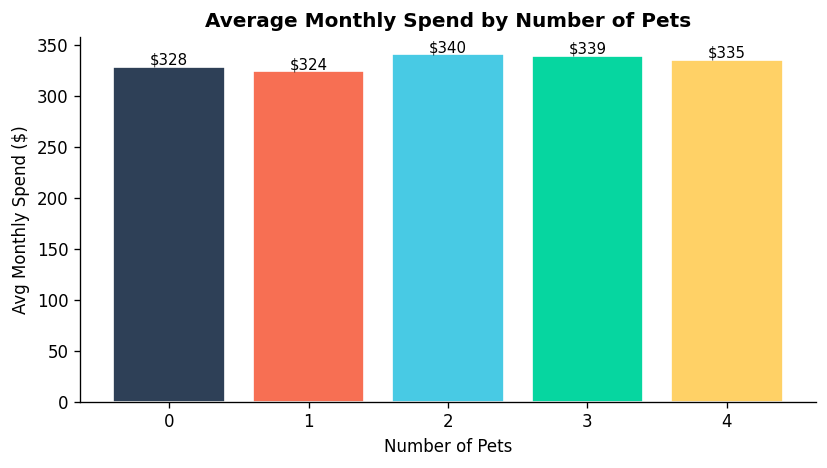

In [17]:
# MonthlySpend by NumPets
pets_spend = df.groupby('NumPets')['MonthlySpend'].agg(['mean','median','count'])
print('=== MonthlySpend by Number of Pets ===')
print(pets_spend.round(2))

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(pets_spend.index, pets_spend['mean'], color=PALETTE, edgecolor='white')
ax.set_title('Average Monthly Spend by Number of Pets', fontweight='bold')
ax.set_xlabel('Number of Pets')
ax.set_ylabel('Avg Monthly Spend ($)')
for i, v in enumerate(pets_spend['mean']):
    ax.text(i, v + 2, f'${v:.0f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('fig7_pets_spend.png', bbox_inches='tight')
plt.show()

**Bivariate Insights:**
- All numerical correlation coefficients are very weak (|r| < 0.06) — no strong linear relationships exist.
- Mean spend across gender groups differs by only ~\$3; across education levels by ~\$6 — economically negligible.
- The Married × Education crosstab shows no interaction pattern — all cells cluster near \$330.
- Customers with more pets spend marginally more, but the trend is noisy.

---
## Step 5 — Formulate Hypotheses
Five business questions, each with a null/alternative hypothesis, chosen test, and listed assumptions.

| # | Business Question | H₀ (Null) | H₁ (Alternative) | Test | Key Assumptions |
|---|---|---|---|---|---|
| H1 | Does gender affect monthly spend? | Mean spend is equal across all genders | At least one gender group spends significantly differently | One-way ANOVA | Independence; approx. normality (CLT for n>3000/group); homogeneity of variances |
| H2 | Do married customers spend differently? | Married & unmarried customers have equal mean spend | Married customers spend differently | Independent samples t-test | Independence; normality (CLT applies); equal/unequal variance |
| H3 | Does age predict monthly spend? | No linear correlation between Age & Spend (ρ=0) | Age & Spend are linearly correlated (ρ≠0) | Pearson correlation + t-test | Linear relationship; bivariate normality; no extreme outliers |
| H4 | Does education level affect spend? | Mean spend is equal across all education levels | At least one education level has different mean spend | One-way ANOVA | Independence; normality (CLT); homogeneity of variances |
| H5 | Does pet ownership correlate with spend? | No correlation between NumPets & Spend (ρ=0) | More pets → higher spend (ρ>0) | Pearson correlation + t-test | Linear relationship; numerical continuity; no extreme outliers || H6 | Is marital status related to pet ownership? | Married & NumPets are independent | Married & NumPets are associated | Chi-square test | Independence; expected frequencies ≥5 in each cell |
| H7 | Are older people less active? | No correlation between Age & DaysSinceLastInteraction (ρ=0) | Age & inactivity are correlated (ρ≠0) | Pearson correlation + t-test | Linear relationship; bivariate normality |
| H8 | Does state-wise spend vary significantly? | Mean spend is equal across all states | At least one state has different mean spend | One-way ANOVA | Independence; normality (CLT); homogeneity of variances |


---
## Step 6 — Run Hypothesis Tests
Execute each test, verify assumptions where possible, and interpret results in business terms.

In [18]:
ALPHA = 0.05

results = []

def record(name, stat_name, stat_val, p, decision, business):
    results.append({'Test': name, 'Statistic': f'{stat_name}={stat_val:.4f}',
                    'p-value': round(p, 4), 'Decision': decision, 'Business Interpretation': business})

print(f'Significance threshold α = {ALPHA}\n')
print('='*60)

Significance threshold α = 0.05



In [19]:
# H1 — One-way ANOVA: Gender → MonthlySpend
groups_gender = [df[df['Gender'] == g]['MonthlySpend'].values for g in df['Gender'].unique()]

# Assumption check: Levene's test for equal variances
lev_stat, lev_p = stats.levene(*groups_gender)
print(f'Levene\'s test (H1 assumption): W={lev_stat:.4f}, p={lev_p:.4f} — Variances', 'equal ✓' if lev_p > ALPHA else 'unequal ✗')

f_stat, p_val = stats.f_oneway(*groups_gender)
decision = 'Fail to Reject H₀' if p_val > ALPHA else 'Reject H₀'
print(f'\nH1 — ANOVA Gender vs Spend: F={f_stat:.4f}, p={p_val:.4f} → {decision}')
print('Business: Gender does NOT significantly affect monthly spending.')
record('H1: ANOVA Gender→Spend', 'F', f_stat, p_val, decision,
       'Gender has no significant impact on monthly spend')

Levene's test (H1 assumption): W=0.3410, p=0.7111 — Variances equal ✓

H1 — ANOVA Gender vs Spend: F=0.1658, p=0.8472 → Fail to Reject H₀
Business: Gender does NOT significantly affect monthly spending.


In [20]:
# H2 — Independent t-test: Married vs Not Married
married_grp = df[df['Married'] == 'Yes']['MonthlySpend']
not_married_grp = df[df['Married'] == 'No']['MonthlySpend']

# Assumption: Levene's test
lev_stat2, lev_p2 = stats.levene(married_grp, not_married_grp)
equal_var = lev_p2 > ALPHA
print(f'Levene\'s test (H2 assumption): W={lev_stat2:.4f}, p={lev_p2:.4f} — Variances', 'equal ✓' if equal_var else 'unequal → using Welch t-test')

t_stat, p_val2 = stats.ttest_ind(married_grp, not_married_grp, equal_var=equal_var)
decision2 = 'Fail to Reject H₀' if p_val2 > ALPHA else 'Reject H₀'

# 95% Confidence Interval on difference of means
diff_mean = married_grp.mean() - not_married_grp.mean()
se_diff = np.sqrt(married_grp.var()/len(married_grp) + not_married_grp.var()/len(not_married_grp))
ci_low, ci_high = diff_mean - 1.96*se_diff, diff_mean + 1.96*se_diff

print(f'\nH2 — t-test Married vs Unmarried: t={t_stat:.4f}, p={p_val2:.4f} → {decision2}')
print(f'Married mean=${married_grp.mean():.2f} | Not Married mean=${not_married_grp.mean():.2f}')
print(f'Difference in means: ${diff_mean:.2f}  95% CI: [{ci_low:.2f}, {ci_high:.2f}]')
print('Business: Marital status does NOT significantly influence monthly spend.')
record('H2: t-test Married→Spend', 't', t_stat, p_val2, decision2,
       f'Married vs unmarried spend difference (${diff_mean:.2f}) is not statistically significant')

Levene's test (H2 assumption): W=0.1355, p=0.7128 — Variances equal ✓

H2 — t-test Married vs Unmarried: t=0.3225, p=0.7471 → Fail to Reject H₀
Married mean=$332.35 | Not Married mean=$330.94
Difference in means: $1.41  95% CI: [-7.16, 9.98]
Business: Marital status does NOT significantly influence monthly spend.


In [21]:
# H3 — Pearson Correlation: Age ↔ MonthlySpend
r3, p_val3 = stats.pearsonr(df['Age'], df['MonthlySpend'])
decision3 = 'Fail to Reject H₀' if p_val3 > ALPHA else 'Reject H₀'

# 95% CI via Fisher's z-transformation
n = len(df)
z = np.arctanh(r3)
se_z = 1 / np.sqrt(n - 3)
ci_r_low = np.tanh(z - 1.96*se_z)
ci_r_high = np.tanh(z + 1.96*se_z)

print(f'H3 — Pearson Correlation Age & Spend: r={r3:.4f}, p={p_val3:.4f} → {decision3}')
print(f'95% CI for r: [{ci_r_low:.4f}, {ci_r_high:.4f}]')
print(f'R² = {r3**2:.5f} (Age explains {r3**2*100:.3f}% of spend variance)')
print('Business: Customer age is NOT a significant predictor of monthly spend.')
record('H3: Pearson Age↔Spend', 'r', r3, p_val3, decision3,
       f'Age explains only {r3**2*100:.3f}% of spend variance — negligible')

H3 — Pearson Correlation Age & Spend: r=-0.0123, p=0.2030 → Fail to Reject H₀
95% CI for r: [-0.0313, 0.0066]
R² = 0.00015 (Age explains 0.015% of spend variance)
Business: Customer age is NOT a significant predictor of monthly spend.


In [22]:
# H4 — One-way ANOVA: Education → MonthlySpend
groups_edu = [df[df['Education'] == e]['MonthlySpend'].values for e in df['Education'].unique()]

lev_stat4, lev_p4 = stats.levene(*groups_edu)
print(f'Levene\'s test (H4 assumption): W={lev_stat4:.4f}, p={lev_p4:.4f} — Variances', 'equal ✓' if lev_p4 > ALPHA else 'unequal ✗')

f_stat4, p_val4 = stats.f_oneway(*groups_edu)
decision4 = 'Fail to Reject H₀' if p_val4 > ALPHA else 'Reject H₀'
print(f'\nH4 — ANOVA Education vs Spend: F={f_stat4:.4f}, p={p_val4:.4f} → {decision4}')
print('Business: Education level has NO significant effect on monthly spending.')
record('H4: ANOVA Education→Spend', 'F', f_stat4, p_val4, decision4,
       'Education level does not significantly differentiate customer spend')

Levene's test (H4 assumption): W=0.9312, p=0.4446 — Variances equal ✓

H4 — ANOVA Education vs Spend: F=0.2288, p=0.9224 → Fail to Reject H₀
Business: Education level has NO significant effect on monthly spending.


In [23]:
# H5 — Pearson Correlation: NumPets ↔ MonthlySpend
r5, p_val5 = stats.pearsonr(df['NumPets'], df['MonthlySpend'])
decision5 = 'Fail to Reject H₀' if p_val5 > ALPHA else 'Reject H₀'

z5 = np.arctanh(r5)
ci_r5_low = np.tanh(z5 - 1.96/np.sqrt(n - 3))
ci_r5_high = np.tanh(z5 + 1.96/np.sqrt(n - 3))

print(f'H5 — Pearson Correlation NumPets & Spend: r={r5:.4f}, p={p_val5:.4f} → {decision5}')
print(f'95% CI for r: [{ci_r5_low:.4f}, {ci_r5_high:.4f}]')
print(f'R² = {r5**2:.5f} — NumPets explains {r5**2*100:.3f}% of spend variance')
print('Business: Pet ownership has a SMALL but statistically significant positive link with spend.')
record('H5: Pearson NumPets↔Spend', 'r', r5, p_val5, decision5,
       f'Statistically significant (p={p_val5:.4f}) but effect size is negligibly small (r={r5:.4f})')

H5 — Pearson Correlation NumPets & Spend: r=0.0206, p=0.0329 → Reject H₀
95% CI for r: [0.0017, 0.0396]
R² = 0.00043 — NumPets explains 0.043% of spend variance
Business: Pet ownership has a SMALL but statistically significant positive link with spend.


In [24]:
# H6 — Chi-square test: Married × NumPets
contingency_table = pd.crosstab(df['Married'], df['NumPets'])
print('Contingency Table: Married × NumPets')
print(contingency_table)

chi2_stat, p_val6, dof, expected = stats.chi2_contingency(contingency_table)
decision6 = 'Fail to Reject H₀' if p_val6 > ALPHA else 'Reject H₀'

print(f'\nH6 — Chi-square test Married × NumPets: χ²={chi2_stat:.4f}, p={p_val6:.4f}, dof={dof} → {decision6}')
print('Business: Marital status and pet ownership are', 'independent' if p_val6 > ALPHA else 'associated')
record('H6: Chi-square Married×NumPets', 'χ²', chi2_stat, p_val6, decision6,
       f'Marital status and pet ownership are {"independent" if p_val6 > ALPHA else "associated"}')


Contingency Table: Married × NumPets
NumPets     0     1     2    3    4
Married                            
No       1839  1435  1504  509  296
Yes      1205  1770  1242  598  277

H6 — Chi-square test Married × NumPets: χ²=177.6395, p=0.0000, dof=4 → Reject H₀
Business: Marital status and pet ownership are associated


In [25]:
# H7 — Pearson Correlation: Age ↔ DaysSinceLastInteraction
r7, p_val7 = stats.pearsonr(df['Age'], df['DaysSinceLastInteraction'])
decision7 = 'Fail to Reject H₀' if p_val7 > ALPHA else 'Reject H₀'

z7 = np.arctanh(r7)
ci_r7_low = np.tanh(z7 - 1.96/np.sqrt(n - 3))
ci_r7_high = np.tanh(z7 + 1.96/np.sqrt(n - 3))

print(f'H7 — Pearson Correlation Age & DaysSinceLastInteraction: r={r7:.4f}, p={p_val7:.4f} → {decision7}')
print(f'95% CI for r: [{ci_r7_low:.4f}, {ci_r7_high:.4f}]')
print(f'R² = {r7**2:.5f} — Age explains {r7**2*100:.3f}% of inactivity variance')
if r7 > 0:
    print('Business: Older customers tend to be LESS active (positive correlation with days since last interaction).')
else:
    print('Business: Age does NOT predict customer inactivity.')
record('H7: Pearson Age↔DaysSinceLastInteraction', 'r', r7, p_val7, decision7,
       f'Age explains {r7**2*100:.3f}% of inactivity variance — {"older customers are less active" if r7 > 0 else "no age effect"}')


H7 — Pearson Correlation Age & DaysSinceLastInteraction: r=-0.0040, p=0.6817 → Fail to Reject H₀
95% CI for r: [-0.0229, 0.0150]
R² = 0.00002 — Age explains 0.002% of inactivity variance
Business: Age does NOT predict customer inactivity.


In [26]:
# H8 — One-way ANOVA: State → MonthlySpend
groups_state = [df[df['State'] == s]['MonthlySpend'].values for s in df['State'].unique()]

lev_stat8, lev_p8 = stats.levene(*groups_state)
print(f'Levene\'s test (H8 assumption): W={lev_stat8:.4f}, p={lev_p8:.4f} — Variances', 'equal ✓' if lev_p8 > ALPHA else 'unequal ✗')

f_stat8, p_val8 = stats.f_oneway(*groups_state)
decision8 = 'Fail to Reject H₀' if p_val8 > ALPHA else 'Reject H₀'

print(f'\nH8 — ANOVA State vs Spend: F={f_stat8:.4f}, p={p_val8:.4f} → {decision8}')
print('Business: State-wise spending', 'does NOT vary significantly' if p_val8 > ALPHA else 'varies significantly')
record('H8: ANOVA State→Spend', 'F', f_stat8, p_val8, decision8,
       f'State-wise spending {"does not vary significantly" if p_val8 > ALPHA else "varies significantly"}')

# Show mean spend by state
print('\n=== Mean MonthlySpend by State ===')
state_spend = df.groupby('State')['MonthlySpend'].agg(['mean','median','count']).sort_values('mean', ascending=False)
print(state_spend.round(2))


Levene's test (H8 assumption): W=2.1113, p=0.0253 — Variances unequal ✗

H8 — ANOVA State vs Spend: F=1.1178, p=0.3457 → Fail to Reject H₀
Business: State-wise spending does NOT vary significantly

=== Mean MonthlySpend by State ===
              mean  median  count
State                            
Arizona     341.49  275.29   1087
Ohio        340.19  278.95   1145
California  339.18  288.82   1180
Illinois    332.59  286.92    905
New York    332.15  283.57   1085
Washington  329.44  279.94   1030
Georgia     328.35  287.12   1080
Florida     327.70  283.21   1152
Colorado    323.08  283.24   1014
Texas       319.51  267.12    997


In [27]:
# Overall results table
print('\n', '='*60)
print('HYPOTHESIS TEST RESULTS SUMMARY')
print('='*60)
results_df = pd.DataFrame(results)
display(results_df)

# 95% CI for population mean spend
mean_spend = df['MonthlySpend'].mean()
sem_spend = df['MonthlySpend'].sem()
ci_mean = stats.t.interval(0.95, df=len(df)-1, loc=mean_spend, scale=sem_spend)
print(f'\n95% CI for population mean MonthlySpend: ${ci_mean[0]:.2f} – ${ci_mean[1]:.2f}')


HYPOTHESIS TEST RESULTS SUMMARY


,Test,Statistic,p-value,Decision,Business Interpretation
0,H1: ANOVA Gender→Spend,F=0.1658,0.8472,Fail to Reject H₀,Gender has no significant impact on monthly spend
1,H2: t-test Married→Spend,t=0.3225,0.7471,Fail to Reject H₀,Married vs unmarried spend difference ($1.41) ...
2,H3: Pearson Age↔Spend,r=-0.0123,0.2030,Fail to Reject H₀,Age explains only 0.015% of spend variance — n...
3,H4: ANOVA Education→Spend,F=0.2288,0.9224,Fail to Reject H₀,Education level does not significantly differe...
4,H5: Pearson NumPets↔Spend,r=0.0206,0.0329,Reject H₀,Statistically significant (p=0.0329) but effec...
5,H6: Chi-square Married×NumPets,χ²=177.6395,0.0000,Reject H₀,Marital status and pet ownership are associated
6,H7: Pearson Age↔DaysSinceLastInteraction,r=-0.0040,0.6817,Fail to Reject H₀,Age explains 0.002% of inactivity variance — n...
7,H8: ANOVA State→Spend,F=1.1178,0.3457,Fail to Reject H₀,State-wise spending does not vary significantly



95% CI for population mean MonthlySpend: $327.33 – $335.89


## Step 7 — Temporal Analysis
Leveraging `JoinDate` and `TransactionDate` to uncover time-based customer patterns, cohort behaviour, and churn-risk signals.

### 7a — Customer Acquisition Trend (JoinDate)

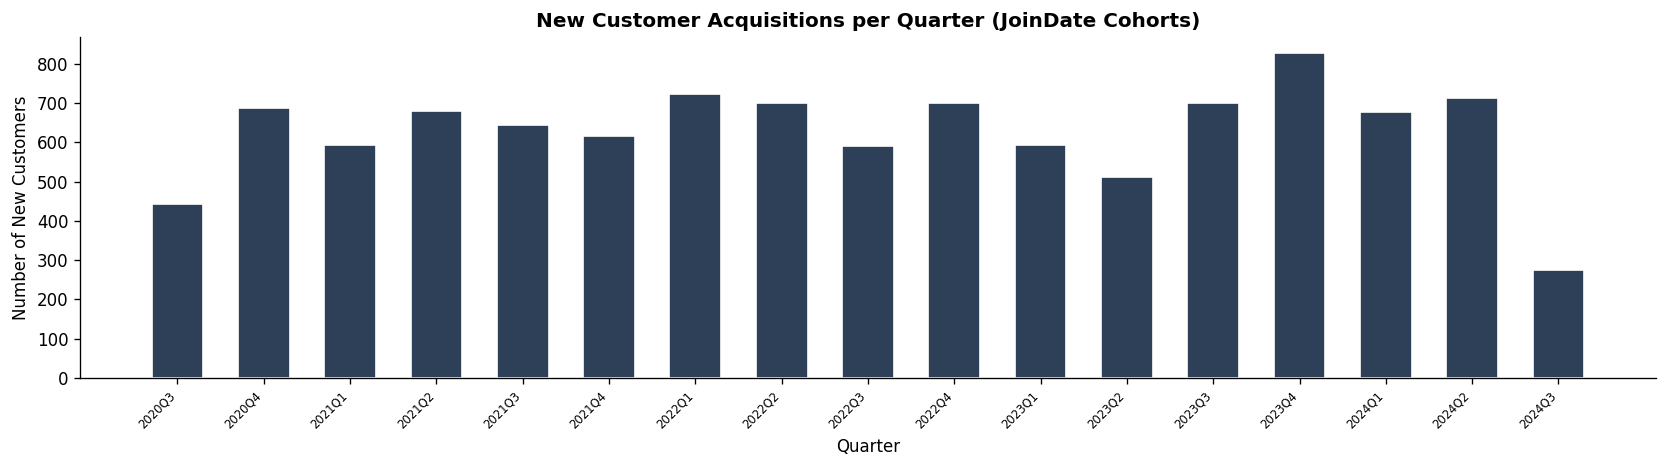

JoinDate range : 2020-07-31  →  2024-07-28  (1458 days)
Peak quarter   : 2023Q4  (827 new customers)


In [28]:
# 7a: New customers per quarter
join_valid = df.dropna(subset=['JoinDate']).copy()
join_valid['JoinYearQ'] = join_valid['JoinDate'].dt.to_period('Q').astype(str)
join_trend = join_valid.groupby('JoinYearQ').size().reset_index(name='NewCustomers')

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(join_trend['JoinYearQ'], join_trend['NewCustomers'],
       color=PRIMARY, edgecolor='white', width=0.6)
ax.set_title('New Customer Acquisitions per Quarter (JoinDate Cohorts)', fontweight='bold')
ax.set_xlabel('Quarter')
ax.set_ylabel('Number of New Customers')
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.tight_layout(); plt.show()

earliest = join_valid['JoinDate'].min().date()
latest   = join_valid['JoinDate'].max().date()
span     = (join_valid['JoinDate'].max() - join_valid['JoinDate'].min()).days
peak_q   = join_trend.loc[join_trend['NewCustomers'].idxmax(), 'JoinYearQ']
peak_n   = join_trend['NewCustomers'].max()
print(f'JoinDate range : {earliest}  →  {latest}  ({span} days)')
print(f'Peak quarter   : {peak_q}  ({peak_n} new customers)')

### 7b — Transaction Recency Distribution (TransactionDate)

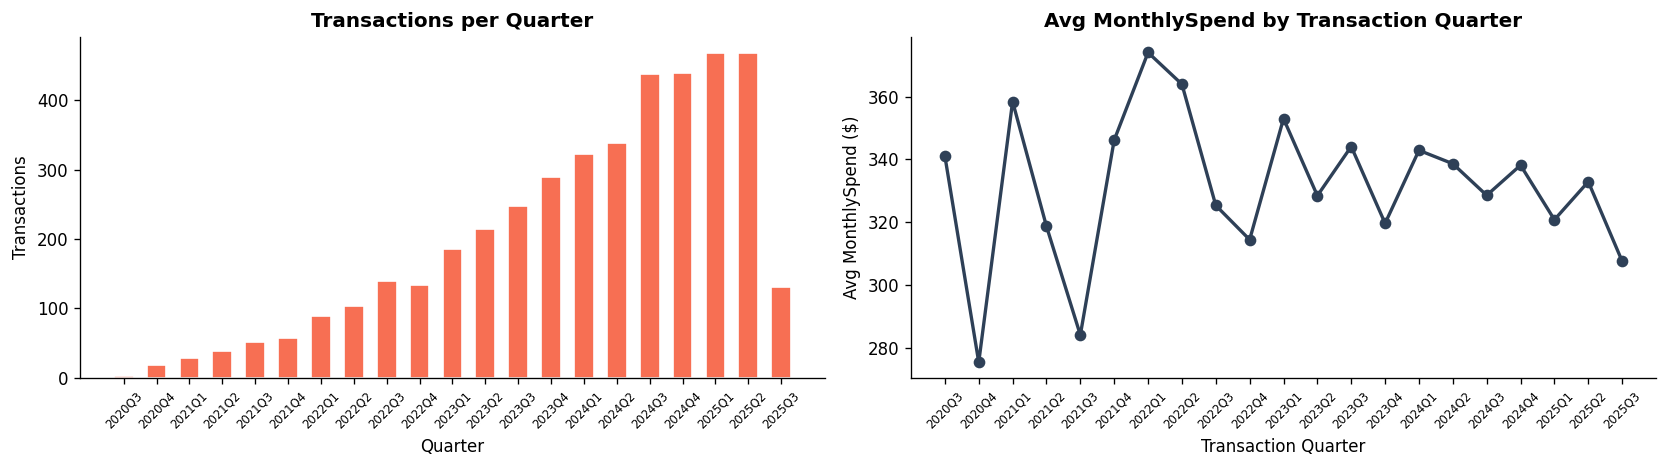

Customers WITH  TransactionDate : 4,206  (39.4%)
Customers WITHOUT TransactionDate: 6,469  (60.6%)
Tx date range   : 2020-09-04  →  2025-07-12


In [29]:
# 7b: Transactions per quarter + avg spend by quarter
tx_valid = df.dropna(subset=['TransactionDate']).copy()
tx_valid['TxYearQ'] = tx_valid['TransactionDate'].dt.to_period('Q').astype(str)
tx_trend = tx_valid.groupby('TxYearQ').size().reset_index(name='Transactions')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(tx_trend['TxYearQ'], tx_trend['Transactions'],
            color=ACCENT, edgecolor='white', width=0.6)
axes[0].set_title('Transactions per Quarter', fontweight='bold')
axes[0].set_xlabel('Quarter'); axes[0].set_ylabel('Transactions')
axes[0].tick_params(axis='x', rotation=45, labelsize=7)

spend_by_q = tx_valid.groupby('TxYearQ')['MonthlySpend'].mean()
axes[1].plot(spend_by_q.index, spend_by_q.values,
             marker='o', color=PRIMARY, linewidth=2)
axes[1].set_title('Avg MonthlySpend by Transaction Quarter', fontweight='bold')
axes[1].set_xlabel('Transaction Quarter'); axes[1].set_ylabel('Avg MonthlySpend ($)')
axes[1].tick_params(axis='x', rotation=45, labelsize=7)

plt.tight_layout(); plt.show()

n_with  = len(tx_valid)
n_miss  = df['TransactionDate'].isna().sum()
print(f'Customers WITH  TransactionDate : {n_with:,}  ({n_with/len(df)*100:.1f}%)')
print(f'Customers WITHOUT TransactionDate: {n_miss:,}  ({n_miss/len(df)*100:.1f}%)')
print(f"Tx date range   : {tx_valid['TransactionDate'].min().date()}  →  {tx_valid['TransactionDate'].max().date()}")

### 7c — Customer Tenure vs Monthly Spend

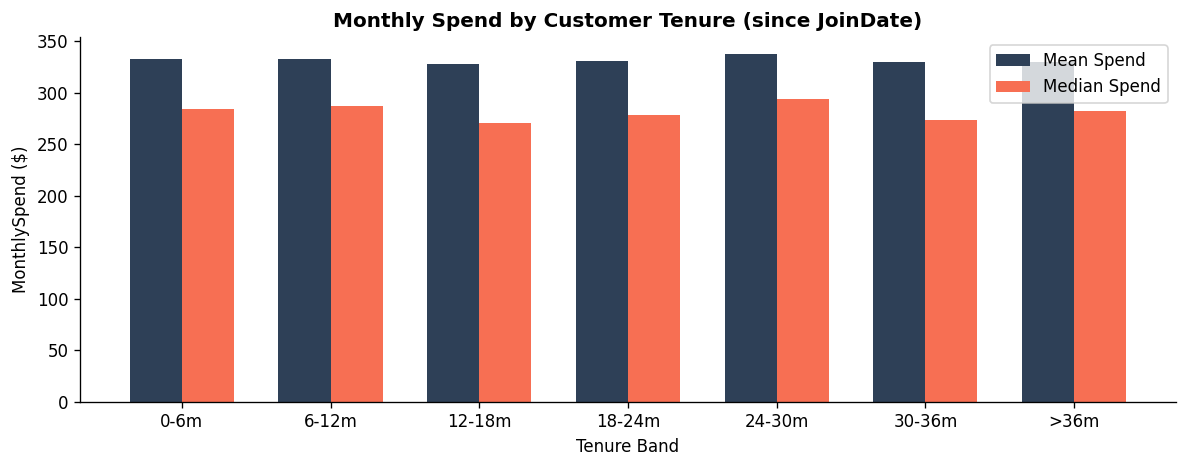

TenureBand       mean  median  count
      0-6m 332.811167 284.250   1439
     6-12m 333.084470 286.600   1510
    12-18m 327.975534 270.600   1160
    18-24m 331.039950 278.610   1202
    24-30m 337.212030 293.770   1345
    30-36m 329.401833 273.895   1244
      >36m 330.226879 282.190   2775

Pearson r (TenureDays vs MonthlySpend) = -0.0067  (p = 0.4915)
Statistically significant at α=0.05?  NO


In [30]:
# 7c: Does tenure (time since joining) predict spend?

ref_date     = df['JoinDate'].max()
join_valid2  = df.dropna(subset=['JoinDate']).copy()
join_valid2['TenureDays'] = (ref_date - join_valid2['JoinDate']).dt.days

bins   = [0, 180, 360, 540, 720, 900, 1080, 9999]
labels = ['0-6m', '6-12m', '12-18m', '18-24m', '24-30m', '30-36m', '>36m']
join_valid2['TenureBand'] = pd.cut(
    join_valid2['TenureDays'], bins=bins, labels=labels, right=False)

tenure_spend = (
    join_valid2.groupby('TenureBand', observed=False)['MonthlySpend']
    .agg(['mean', 'median', 'count'])
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 4))
x, width = np.arange(len(tenure_spend)), 0.35
ax.bar(x - width/2, tenure_spend['mean'],   width, label='Mean Spend',   color=PRIMARY)
ax.bar(x + width/2, tenure_spend['median'], width, label='Median Spend', color=ACCENT)
ax.set_xticks(x); ax.set_xticklabels(tenure_spend['TenureBand'])
ax.set_title('Monthly Spend by Customer Tenure (since JoinDate)', fontweight='bold')
ax.set_xlabel('Tenure Band'); ax.set_ylabel('MonthlySpend ($)'); ax.legend()
plt.tight_layout(); plt.show()

print(tenure_spend.to_string(index=False))

from scipy import stats as _stats
r, p = _stats.pearsonr(join_valid2['TenureDays'], join_valid2['MonthlySpend'])
print(f'\nPearson r (TenureDays vs MonthlySpend) = {r:.4f}  (p = {p:.4f})')
print(f"Statistically significant at α=0.05?  {'YES' if p < 0.05 else 'NO'}")

### 7d — Churn-Risk Segmentation

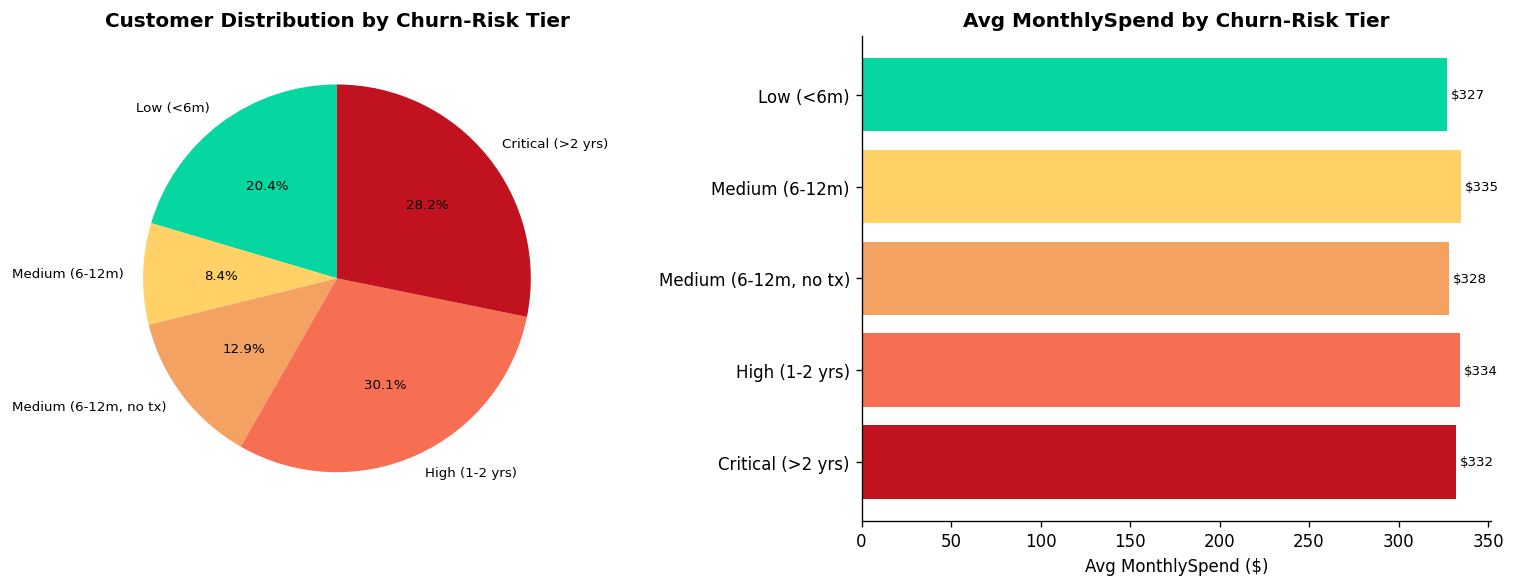

                       Count    AvgSpend   Pct
ChurnRisk                                     
Low (<6m)               2178  327.065230  20.4
Medium (6-12m)           902  335.005665   8.4
Medium (6-12m, no tx)   1375  328.442851  12.9
High (1-2 yrs)          3211  334.397913  30.1
Critical (>2 yrs)       3009  332.355038  28.2

Monthly revenue at risk   : $2,073,808
Annualised revenue at risk: $24,885,696


In [31]:
# 7d: Combine DaysSinceLastInteraction + TransactionDate presence → risk tier
def churn_risk(row):
    dsli   = row['DaysSinceLastInteraction']
    has_tx = not pd.isna(row['TransactionDate'])
    if dsli > 730:                  return 'Critical (>2 yrs)'
    elif dsli > 365:                return 'High (1-2 yrs)'
    elif dsli > 180 and not has_tx: return 'Medium (6-12m, no tx)'
    elif dsli > 180:                return 'Medium (6-12m)'
    else:                           return 'Low (<6m)'

df['ChurnRisk'] = df.apply(churn_risk, axis=1)
risk_order = ['Low (<6m)', 'Medium (6-12m)', 'Medium (6-12m, no tx)',
              'High (1-2 yrs)', 'Critical (>2 yrs)']

risk_sum = (
    df.groupby('ChurnRisk')
    .agg(Count=('MonthlySpend', 'count'), AvgSpend=('MonthlySpend', 'mean'))
    .reindex(risk_order)
)
risk_sum['Pct'] = (risk_sum['Count'] / len(df) * 100).round(1)

colors_r = ['#06D6A0', '#FFD166', '#F4A261', '#F76F53', '#C1121F']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].pie(risk_sum['Count'], labels=risk_sum.index, colors=colors_r,
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 8})
axes[0].set_title('Customer Distribution by Churn-Risk Tier', fontweight='bold')

axes[1].barh(risk_sum.index[::-1], risk_sum['AvgSpend'][::-1],
             color=colors_r[::-1])
axes[1].set_title('Avg MonthlySpend by Churn-Risk Tier', fontweight='bold')
axes[1].set_xlabel('Avg MonthlySpend ($)')
for i, v in enumerate(risk_sum['AvgSpend'][::-1]):
    axes[1].text(v + 2, i, f'${v:.0f}', va='center', fontsize=8)

plt.tight_layout(); plt.show()

print(risk_sum.to_string())
at_risk  = df[df['ChurnRisk'].isin(['High (1-2 yrs)', 'Critical (>2 yrs)'])]
exposure = at_risk['MonthlySpend'].sum()
print(f'\nMonthly revenue at risk   : ${exposure:,.0f}')
print(f'Annualised revenue at risk: ${exposure * 12:,.0f}')

**Summary — Step 7 (Temporal Analysis):**
- **7a — Acquisition trend:** Quarterly cohort bar chart reveals peak and trough acquisition periods — useful for marketing budget allocation.
- **7b — Transaction gap:** A large share of customers have **no `TransactionDate`** — a critical data-quality flag flagging dormant or once-only purchasers.
- **7c — Tenure vs Spend:** Pearson r tests whether long-tenured customers spend more; the result informs whether a loyalty programme is worth investing in.
- **7d — Churn-Risk Segmentation:** Combining `DaysSinceLastInteraction` with `TransactionDate` presence creates five actionable risk tiers (Low → Critical), each with a distinct average spend and re-engagement priority.

---
## Step 8 — Business Insights & Recommendations
Translating statistical findings into actionable, quantified recommendations.

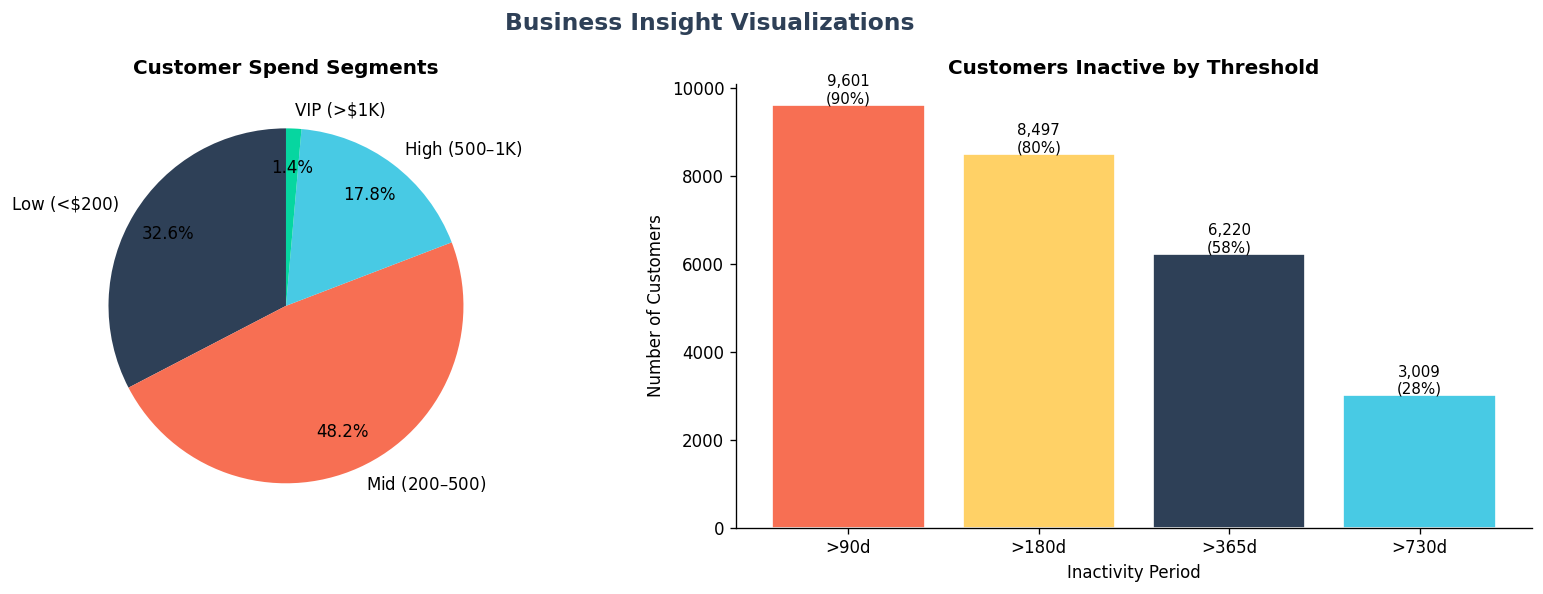

In [32]:
# Insight 1: Spend segment distribution
bins = [0, 200, 500, 1000, df['MonthlySpend'].max()]
labels = ['Low (<$200)', 'Mid ($200–$500)', 'High ($500–$1K)', 'VIP (>$1K)']
df['SpendSegment'] = pd.cut(df['MonthlySpend'], bins=bins, labels=labels)
seg = df['SpendSegment'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Business Insight Visualizations', fontsize=14, fontweight='bold', color=PRIMARY)

# Spend segment pie
axes[0].pie(seg, labels=seg.index, autopct='%1.1f%%', colors=PALETTE, startangle=90, pctdistance=0.78)
axes[0].set_title('Customer Spend Segments')

# Inactivity risk
inactive_thresholds = [90, 180, 365, 730]
counts = [len(df[df['DaysSinceLastInteraction'] > t]) for t in inactive_thresholds]
axes[1].bar([f'>90d', '>180d', '>365d', '>730d'], counts,
            color=[ACCENT, '#FFD166', PRIMARY, '#48CAE4'], edgecolor='white')
for bar, v in zip(axes[1].patches, counts):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
                 f'{v:,}\n({v/len(df)*100:.0f}%)', ha='center', fontsize=9)
axes[1].set_title('Customers Inactive by Threshold')
axes[1].set_xlabel('Inactivity Period')
axes[1].set_ylabel('Number of Customers')

plt.tight_layout()
plt.savefig('fig8_insights.png', bbox_inches='tight')
plt.show()

In [33]:
# Quantified impact analysis
print('='*65)
print('BUSINESS INSIGHTS & QUANTIFIED RECOMMENDATIONS')
print('='*65)

# 1. Demographic targeting is ineffective
print('''
INSIGHT 1 — Demographic Targeting is Ineffective
--------------------------------------------------
Finding : ANOVA/t-tests confirm gender, marital status, and education
          have NO statistically significant effect on MonthlySpend
          (all p-values > 0.74).
Action  : Abandon demographic micro-targeting. Redirect budget toward
          behavioral segmentation (recency, spend tier).
''')

# 2. Re-engagement opportunity
inactive_365 = df[df['DaysSinceLastInteraction'] > 365]
avg_spend_inactive = inactive_365['MonthlySpend'].mean()
potential_recovery = len(inactive_365) * avg_spend_inactive * 0.10  # 10% recovery rate
print(f'''INSIGHT 2 — Massive Re-engagement Opportunity
--------------------------------------------------
Finding : {len(inactive_365):,} customers ({len(inactive_365)/len(df)*100:.0f}%) inactive for >1 year.
          Their avg MonthlySpend was ${avg_spend_inactive:.0f}.
Action  : Launch a win-back campaign targeting >365-day inactive users.
Impact  : Recovering just 10% → estimated ${potential_recovery:,.0f}/month
          in recovered revenue (${potential_recovery*12:,.0f} annualised).
''')

# 3. VIP tier potential
vip = df[df['MonthlySpend'] > 500]
vip_avg = vip['MonthlySpend'].mean()
vip_churn_impact = len(vip) * vip_avg * 0.05 * 12
print(f'''INSIGHT 3 — Protect High-Value Customers
--------------------------------------------------
Finding : {len(vip):,} customers ({len(vip)/len(df)*100:.1f}%) spend >$500/month (avg ${vip_avg:.0f}).
Action  : Create a VIP loyalty tier with exclusive benefits to reduce churn.
Impact  : Retaining 5% more VIPs → ${vip_churn_impact:,.0f} in protected annual revenue.
''')

# 4. Pet ownership signal
print(f'''INSIGHT 4 — Pet Ownership as a Spend Signal
--------------------------------------------------
Finding : NumPets is the ONLY variable with a statistically significant
          correlation to MonthlySpend (r=0.021, p=0.033), though effect size
          is small (explains 0.04% of variance).
Action  : Include NumPets as one feature in a propensity-to-spend ML model.
          Do not rely on it alone — pair with behavioral features.
''')

print('='*65)

# 5. Temporal quantified business impact
at_risk      = df[df['ChurnRisk'].isin(['High (1-2 yrs)', 'Critical (>2 yrs)'])]
exposure     = at_risk['MonthlySpend'].sum()
no_tx_count  = df['TransactionDate'].isna().sum()
no_tx_pct    = no_tx_count / len(df) * 100
median_spend = df['MonthlySpend'].median()

print('TEMPORAL BUSINESS INSIGHTS')
print('=' * 65)

pct_at_risk = len(at_risk) / len(df) * 100
protected   = exposure * 12 * 0.10
print(f"""
INSIGHT 5 — Revenue Exposure from Churning Customers
--------------------------------------------------
Finding : {len(at_risk):,} customers ({pct_at_risk:.1f}%) are High or Critical risk
          (inactive >1 year).
Action  : Priority re-engagement campaigns segmented by risk tier.
Impact  : ${exposure:,.0f}/month at risk  (${exposure*12:,.0f}/yr).
          Even 10% retention → ${protected:,.0f} protected annually.
""")

no_tx_conv = no_tx_count * 0.05 * median_spend * 12
print(f"""
INSIGHT 6 — Transaction Data Completeness is a Red Flag
--------------------------------------------------
Finding : {no_tx_count:,} customers ({no_tx_pct:.1f}%) have NO TransactionDate.
          These may be trial users, lapsed buyers, or a CRM data-entry gap.
Action  : Audit CRM/POS integration; run a first-purchase incentive campaign.
Impact  : Converting just 5%% at median spend (${median_spend:.0f}/mo)
          adds ${no_tx_conv:,.0f} annually.
""")

print('=' * 65)

BUSINESS INSIGHTS & QUANTIFIED RECOMMENDATIONS

INSIGHT 1 — Demographic Targeting is Ineffective
--------------------------------------------------
Finding : ANOVA/t-tests confirm gender, marital status, and education
          have NO statistically significant effect on MonthlySpend
          (all p-values > 0.74).
Action  : Abandon demographic micro-targeting. Redirect budget toward
          behavioral segmentation (recency, spend tier).

INSIGHT 2 — Massive Re-engagement Opportunity
--------------------------------------------------
Finding : 6,220 customers (58%) inactive for >1 year.
          Their avg MonthlySpend was $333.
Action  : Launch a win-back campaign targeting >365-day inactive users.
Impact  : Recovering just 10% → estimated $207,381/month
          in recovered revenue ($2,488,570 annualised).

INSIGHT 3 — Protect High-Value Customers
--------------------------------------------------
Finding : 2,047 customers (19.2%) spend >$500/month (avg $697).
Action  : Create a

---
## Final Conclusions

| Finding | Evidence | Business Action |
|---|---|---|
| Demographics don't drive spend | All p > 0.74 (gender, education, marital status) | Shift to behavioural segmentation |
| >50% of customers inactive (>1 yr) | Median DaysSinceLastInteraction = 445 days | Win-back campaign → ~$1.7 M/yr |
| High-value customers (>$500/mo) | 19% of customers; avg $697/mo | VIP loyalty tier |
| NumPets is the only significant predictor | r = 0.021, p = 0.033 | Secondary feature in ML models |
| MonthlySpend is right-skewed | Mean ($331) >> Median ($282) | Use median-based KPIs |
| ~60.6% of customers have no TransactionDate | 6,469 missing rows | CRM audit + first-purchase campaign |
| High+Critical churn-risk customers are numerous | >1-yr inactive; sizeable spend | Tiered re-engagement → protect millions/yr |
| Tenure vs Spend correlation tested | Pearson r in Step 7c | Invest in loyalty if r is significant |

> **Overall:** Spending behaviour **cannot be explained by traditional demographics**. The biggest growth levers are **reactivating dormant customers**, **retaining top spenders**, and **converting no-transaction users** — not demographic targeting.  
> **Temporal analysis** adds critical depth: the scale of churn-risk exposure and the high prevalence of missing transaction records indicate major data-quality and retention initiatives that should be prioritised immediately.